In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)

In [2]:
#Import des datasets et infos
train, test = pd.read_csv('train.csv'), pd.read_csv('test.csv')
print("Import des datasets reussi !")
print()
print(train.info())
print()
print(test.info())

Import des datasets reussi !

<class 'pandas.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 11 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1290081 non-null  str    
 1   period                      1290081 non-null  int64  
 2   operation                   1290081 non-null  str    
 3   amount                      1290081 non-null  float64
 4   origin_account              1290081 non-null  str    
 5   origin_balance_before       1290081 non-null  float64
 6   origin_balance_after        1290081 non-null  float64
 7   destination_account         1290081 non-null  str    
 8   destination_balance_before  1290081 non-null  float64
 9   destination_balance_after   1290081 non-null  float64
 10  fraud_flag                  1290081 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 108.3 MB
None

<class 'pandas.DataFrame'>
RangeInd

In [3]:
#Verification de doublons
print(f"Doublons parfaits dans train : {train.duplicated(subset=list(train.columns)).sum()}")
print()
print(f"Doublons parfaits dans test : {train.duplicated(subset=list(test.columns)).sum()}")

Doublons parfaits dans train : 0

Doublons parfaits dans test : 0


## Feature engineering

In [4]:
df_train, df_test = train.copy(), test.copy()

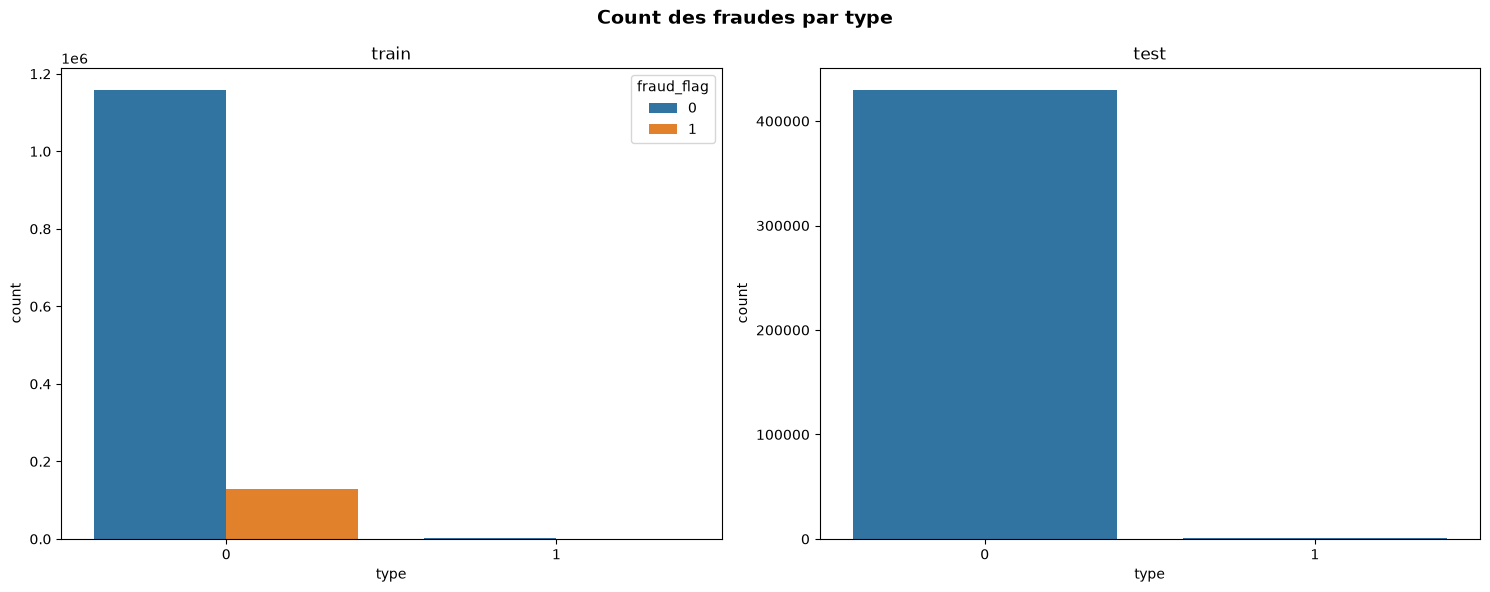

In [5]:
#type : on verifie s'il s'agit d'un debit (0) ou d'un credit (1)
df_train['type']= ((df_train['origin_balance_before']<0.0) & (df_train['origin_balance_after']>0.0)).astype(int)
df_test['type']= ((df_test['origin_balance_before']<0.0) & (df_test['origin_balance_after']>0.0)).astype(int)

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par type", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='type', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='type', ax=ax[1])

plt.tight_layout()
plt.show()

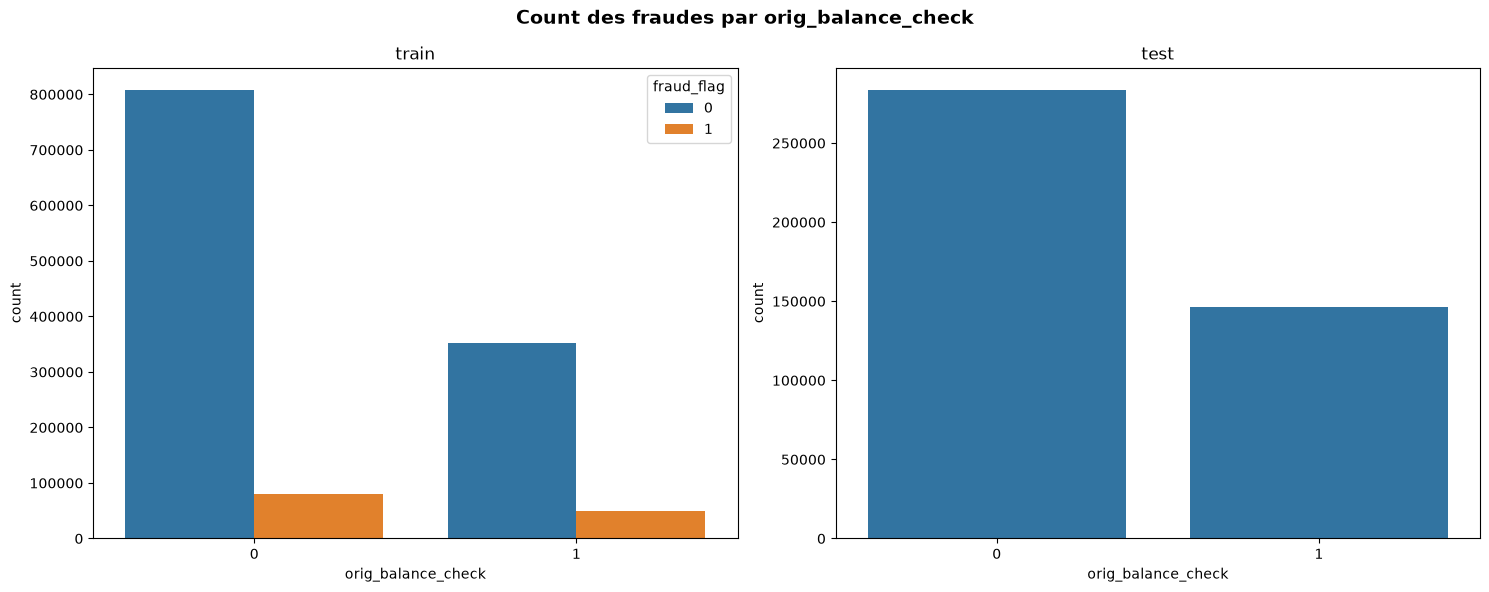

In [6]:
#orig_balance_check : on verifie origin_balance_after = origin_balance_before - amount 
# en faisant attention au type (0 pour debit, 1 pour credit)

df_train['orig_balance_check']= (((df_train['origin_balance_after'] == df_train['origin_balance_before'] - df_train['amount']) & (df_train['type']==0)) 
                                 | 
                                 ((df_train['origin_balance_after'] == df_train['origin_balance_before'] + df_train['amount']) & (df_train['type']==1))).astype(int)  

df_test['orig_balance_check']= (((df_test['origin_balance_after'] == df_test['origin_balance_before'] - df_test['amount']) & (df_test['type']==0)) 
                                 | 
                                 ((df_test['origin_balance_after'] == df_test['origin_balance_before'] + df_test['amount']) & (df_test['type']==1))).astype(int)  

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par orig_balance_check", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='orig_balance_check', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='orig_balance_check', ax=ax[1])

plt.tight_layout()
plt.show()

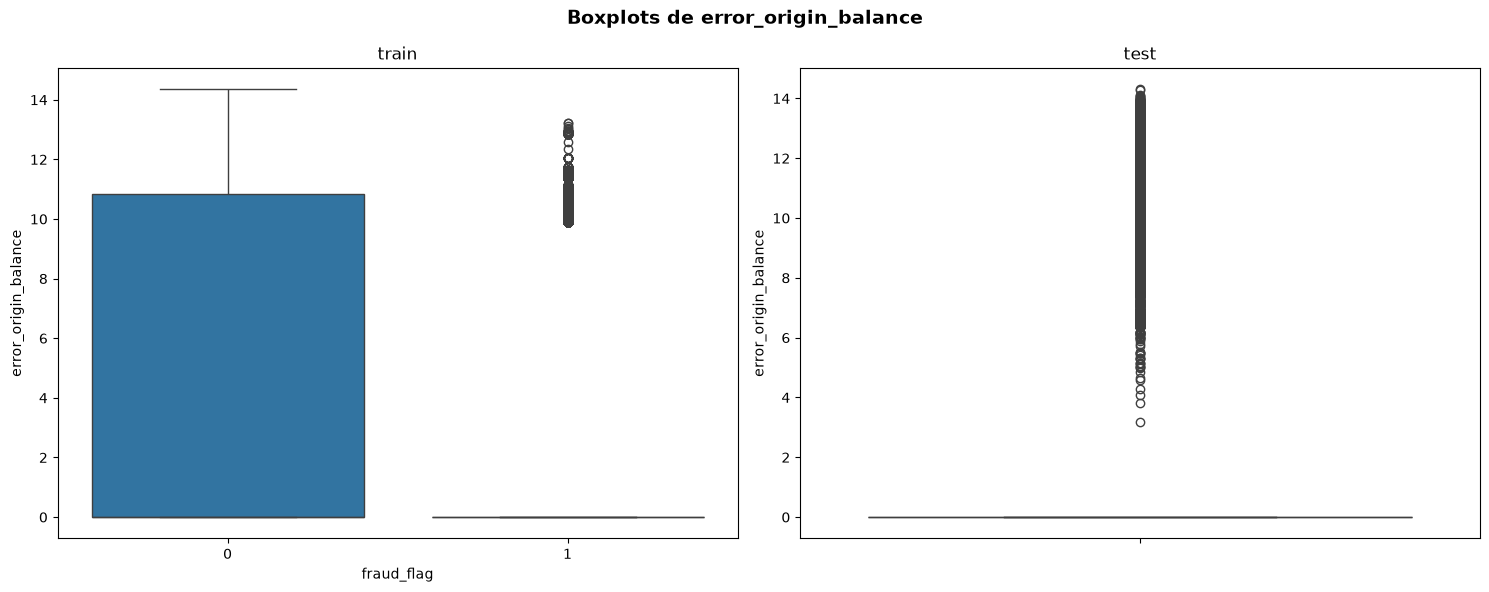

In [7]:
#error_origin_balance : on calcule (origin_balance_before - amount) - origin_balance_after
# en faisant attention au type (0 pour debit, 1 pour credit)


df_train['error_origin_balance'] = np.where(df_train['type']==0, 
                                            np.log1p(np.abs((df_train['origin_balance_before'] - df_train['amount']) - df_train['origin_balance_after'])), 
                                            np.log1p(np.abs((df_train['origin_balance_before'] + df_train['amount']) - df_train['origin_balance_after']))
                                            )

df_test['error_origin_balance'] = np.where(df_test['type']==0, 
                                            np.log1p(np.abs((df_test['origin_balance_before'] - df_test['amount']) - df_test['origin_balance_after'])), 
                                            np.log1p(np.abs((df_test['origin_balance_before'] + df_test['amount']) - df_test['origin_balance_after']))
                                            )


fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Boxplots de error_origin_balance", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.boxplot(df_train, x='fraud_flag', y='error_origin_balance', ax=ax[0])

ax[1].set_title("test")
sns.boxplot(df_test['error_origin_balance'], ax=ax[1])

plt.tight_layout()
plt.show()

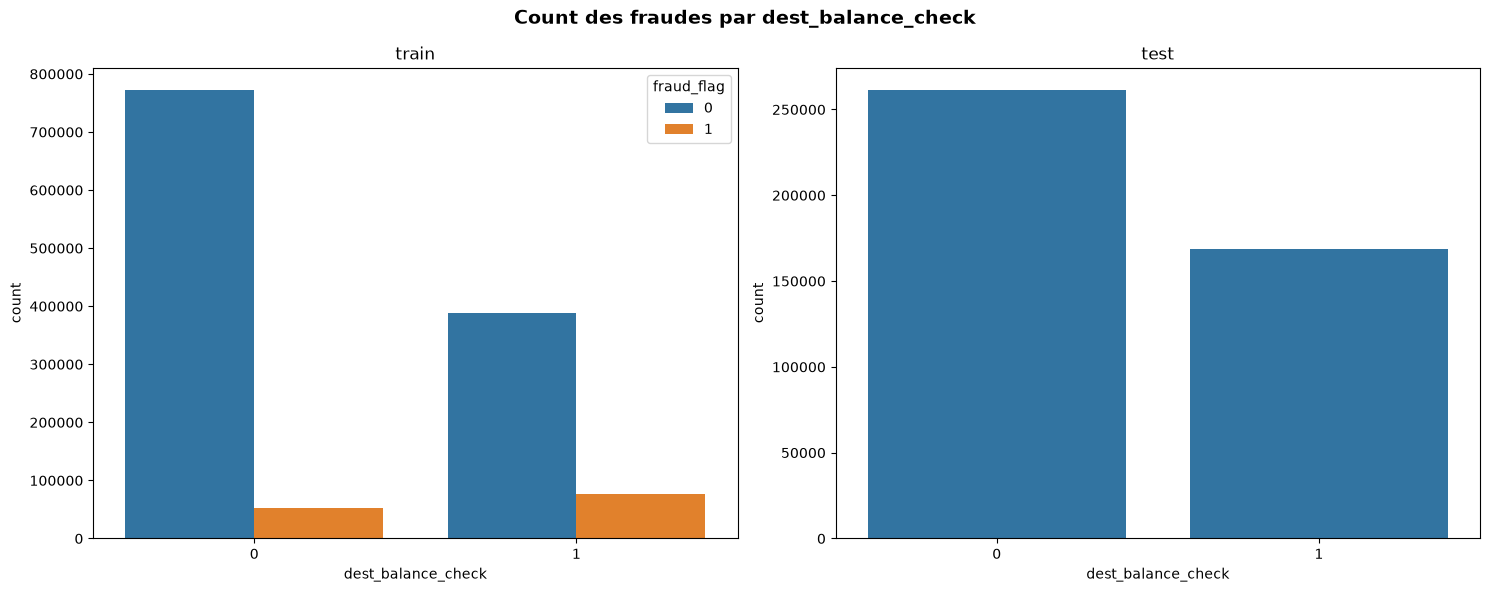

In [8]:
#dest_balance_check : on verifie destination_balance_after = destination_balance_before + amount 
# en faisant attention au type (0 pour debit, 1 pour credit)

df_train['dest_balance_check']= (((df_train['destination_balance_after'] == df_train['destination_balance_before'] + df_train['amount']) & (df_train['type']==0)) 
                                 | 
                                 ((df_train['destination_balance_after'] == df_train['destination_balance_before']) & (df_train['type']==1))).astype(int)  

df_test['dest_balance_check']= (((df_test['destination_balance_after'] == df_test['destination_balance_before'] + df_test['amount']) & (df_test['type']==0)) 
                                 | 
                                 ((df_test['destination_balance_after'] == df_test['destination_balance_before']) & (df_test['type']==1))).astype(int)  

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par dest_balance_check", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='dest_balance_check', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='dest_balance_check', ax=ax[1])

plt.tight_layout()
plt.show()

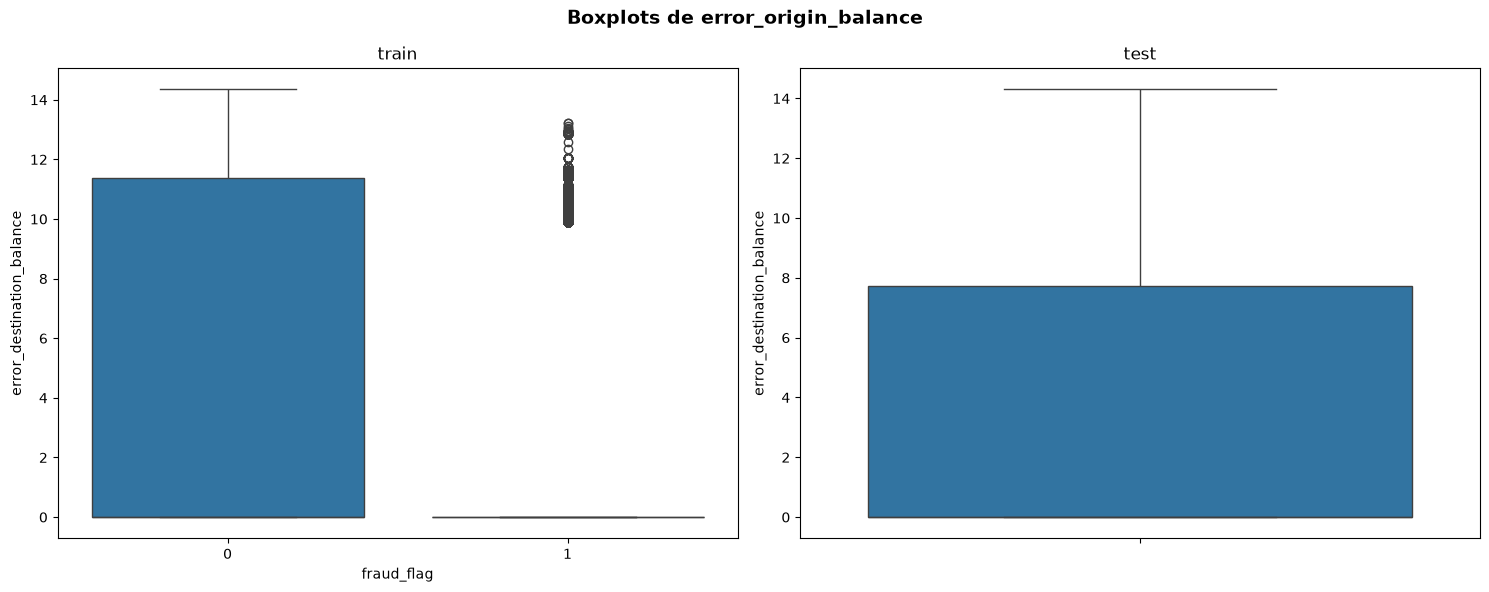

In [9]:
#error_destination_balance : on calcule (origin_balance_before - amount) - origin_balance_after
# en faisant attention au type (0 pour debit, 1 pour credit)


df_train['error_destination_balance'] = np.where(df_train['type']==0, 
                                            np.log1p(np.abs((df_train['destination_balance_before'] + df_train['amount']) - df_train['destination_balance_after'])), 
                                            np.log1p(np.abs(df_train['destination_balance_before'] - df_train['destination_balance_after']))
                                            )

df_test['error_destination_balance'] = np.where(df_test['type']==0, 
                                            np.log1p(np.abs((df_test['destination_balance_before'] + df_test['amount']) - df_test['destination_balance_after'])), 
                                            np.log1p(np.abs(df_test['destination_balance_before'] - df_test['destination_balance_after']))
                                            )


fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Boxplots de error_origin_balance", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.boxplot(df_train, x='fraud_flag', y='error_destination_balance', ax=ax[0])

ax[1].set_title("test")
sns.boxplot(df_test['error_destination_balance'], ax=ax[1])

plt.tight_layout()
plt.show()

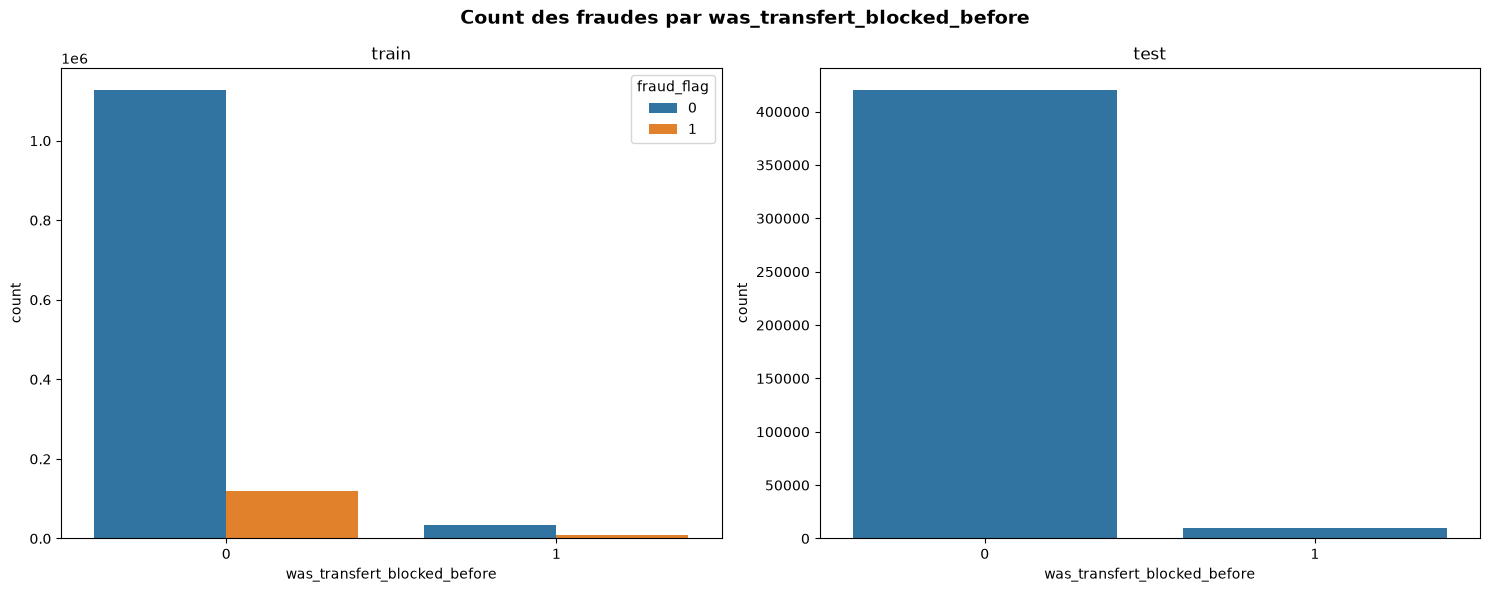

In [10]:
#was_transfert_blocked_before : on verifie origin_balance_before = origin_balance_after

df_train['was_transfert_blocked_before'] = ((df_train['origin_balance_before'] == df_train['origin_balance_after'])).astype(int)
df_test['was_transfert_blocked_before'] = ((df_test['origin_balance_before'] == df_test['origin_balance_after'])).astype(int)

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par was_transfert_blocked_before", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='was_transfert_blocked_before', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='was_transfert_blocked_before', ax=ax[1])

plt.tight_layout()
plt.show()

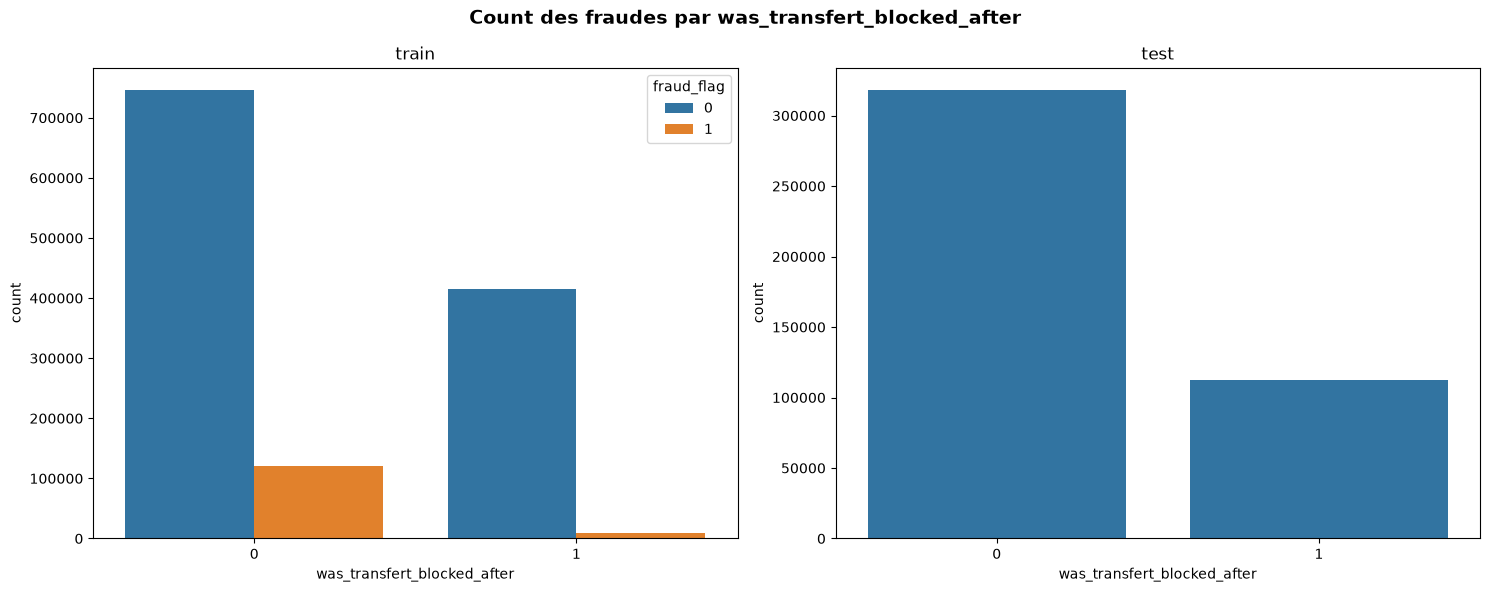

In [11]:
#was_transfert_blocked_after : on verifie origin_balance_before = origin_balance_after

df_train['was_transfert_blocked_after'] = ((df_train['destination_balance_before'] == df_train['destination_balance_after'])).astype(int)
df_test['was_transfert_blocked_after'] = ((df_test['destination_balance_before'] == df_test['destination_balance_after'])).astype(int)

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par was_transfert_blocked_after", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='was_transfert_blocked_after', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='was_transfert_blocked_after', ax=ax[1])

plt.tight_layout()
plt.show()

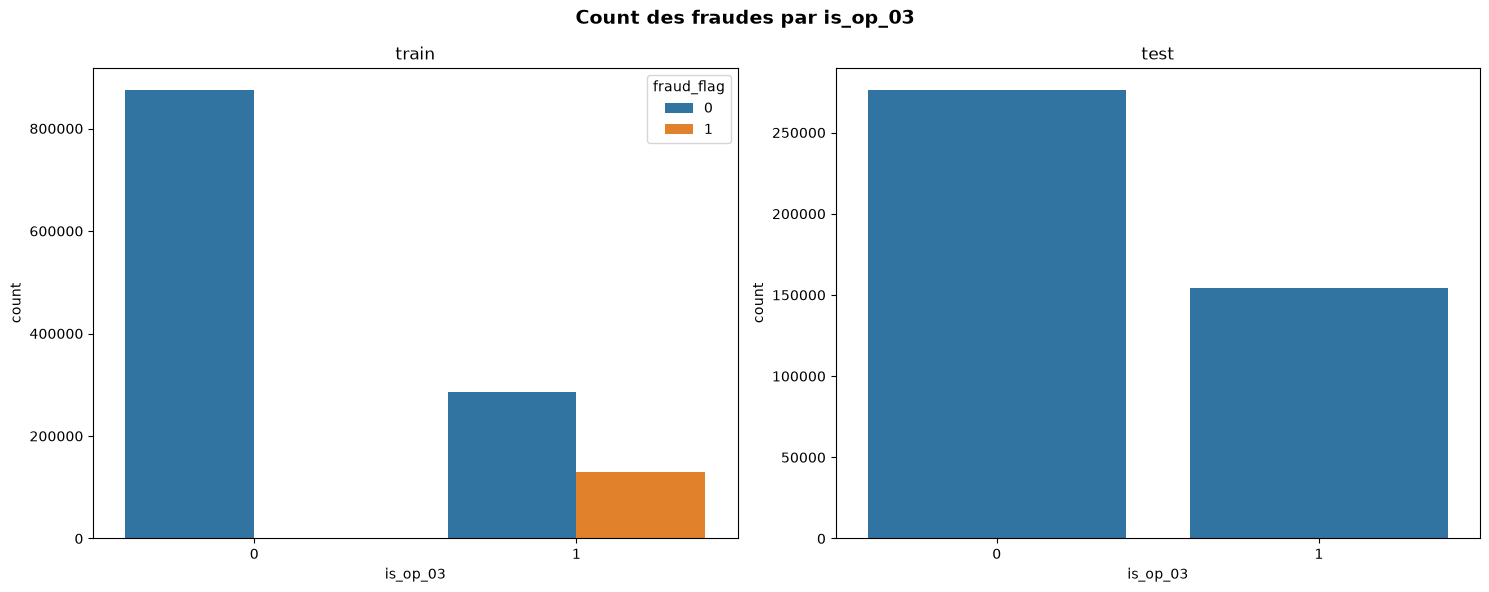

In [12]:
#is_op_03 : on verifie si operation = op_03

df_train['is_op_03']= (df_train['operation'] == 'op_03').astype(int)
df_test['is_op_03']= (df_test['operation'] == 'op_03').astype(int)

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par is_op_03", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='is_op_03', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='is_op_03', ax=ax[1])

plt.tight_layout()
plt.show()

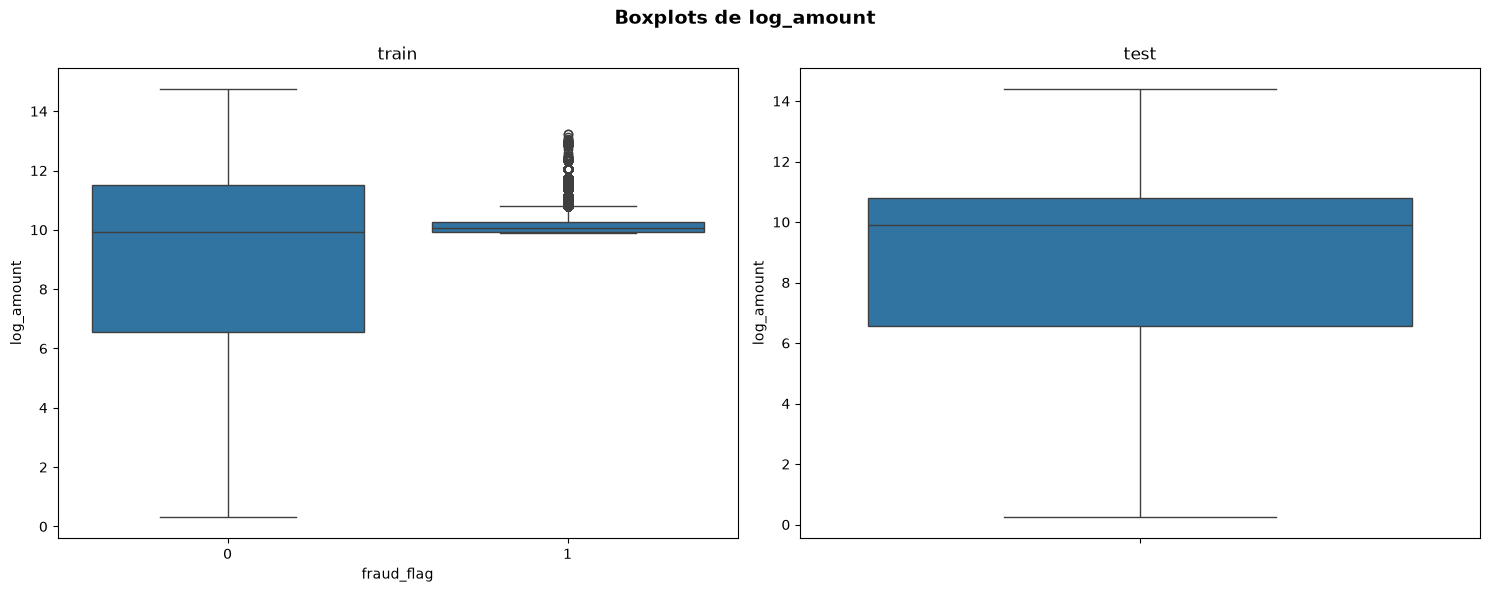

In [13]:
#log_amount : log1p(amount)

df_train['log_amount'] = np.log1p(df_train['amount'])
df_test['log_amount'] = np.log1p(df_test['amount'])

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Boxplots de log_amount", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.boxplot(df_train, x='fraud_flag', y='log_amount', ax=ax[0])

ax[1].set_title("test")
sns.boxplot(df_test['log_amount'], ax=ax[1])

plt.tight_layout()
plt.show()

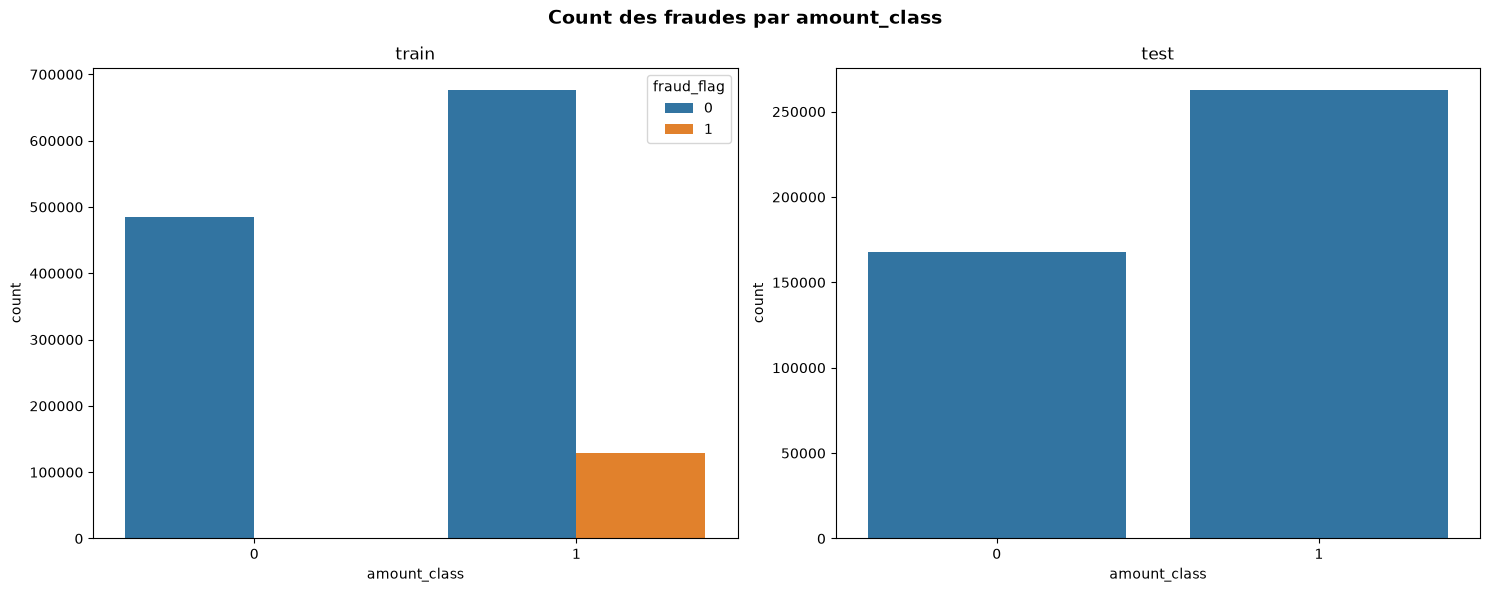

In [14]:
#amount_class : on verifie np.min(df_train[df_train['fraud_flag']==1]['log_amount']) <= log_amount <= np.max(df_train[df_train['fraud_flag']==1]['log_amount'])

thresh1, thresh2 = np.mean(df_train['log_amount']), np.mean(df_test['log_amount'])

df_train['amount_class']= (df_train['log_amount'] > thresh1).astype(int)
df_test['amount_class']= (df_test['log_amount'] > thresh2).astype(int)

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par amount_class", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='amount_class', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='amount_class', ax=ax[1])

plt.tight_layout()
plt.show()

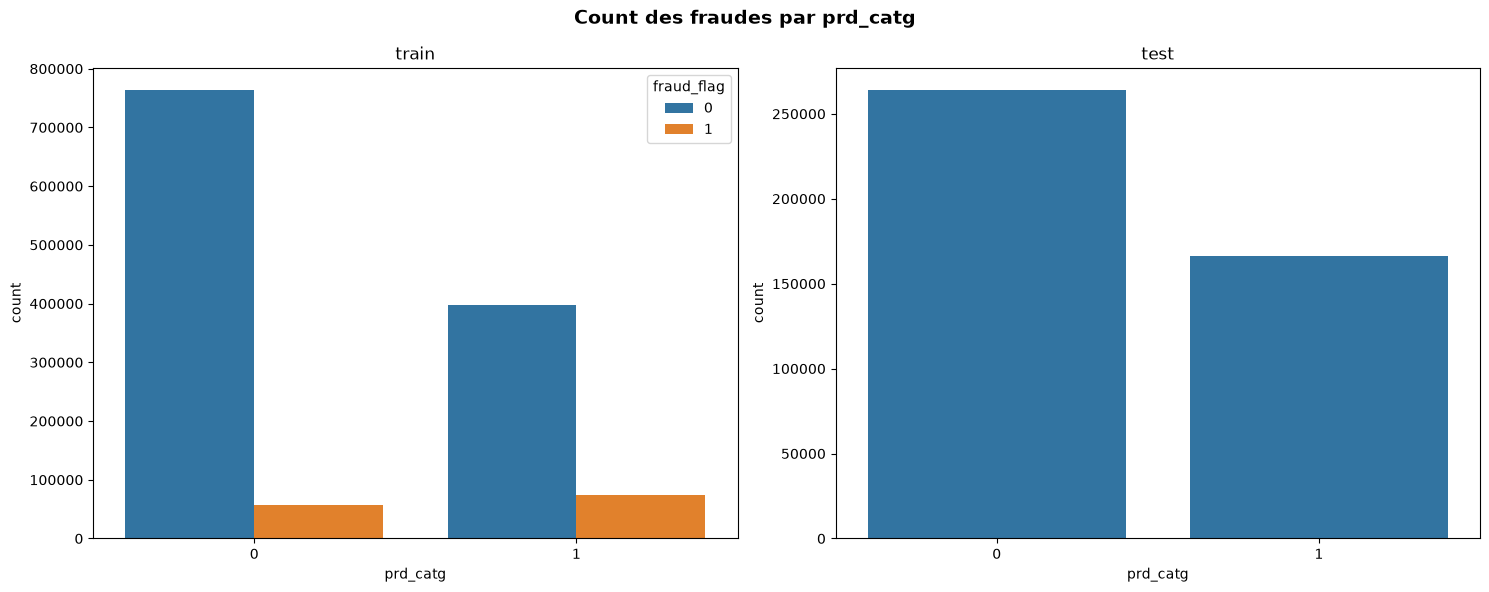

In [15]:
#prd_catg : on verifie si une periode ne contient que les operations op_03 et op_05

def get_map(data : pd.DataFrame, col : str, target : str):
    periods = data[col].unique()
    maps= {}
    for period in periods :
        subset = data[data[col]==period][target]
        if sorted(list(subset.unique())) == ['op_03', 'op_05']:
            maps[period]=1
        else :
            maps[period]=0
    return maps

df_train['prd_catg'] = df_train['period'].map(get_map(df_train, 'period', 'operation'))
df_test['prd_catg'] = df_test['period'].map(get_map(df_test, 'period', 'operation'))

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Count des fraudes par prd_catg", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.countplot(df_train, x='prd_catg', hue='fraud_flag', ax=ax[0])

ax[1].set_title("test")
sns.countplot(df_test, x='prd_catg', ax=ax[1])

plt.tight_layout()
plt.show()

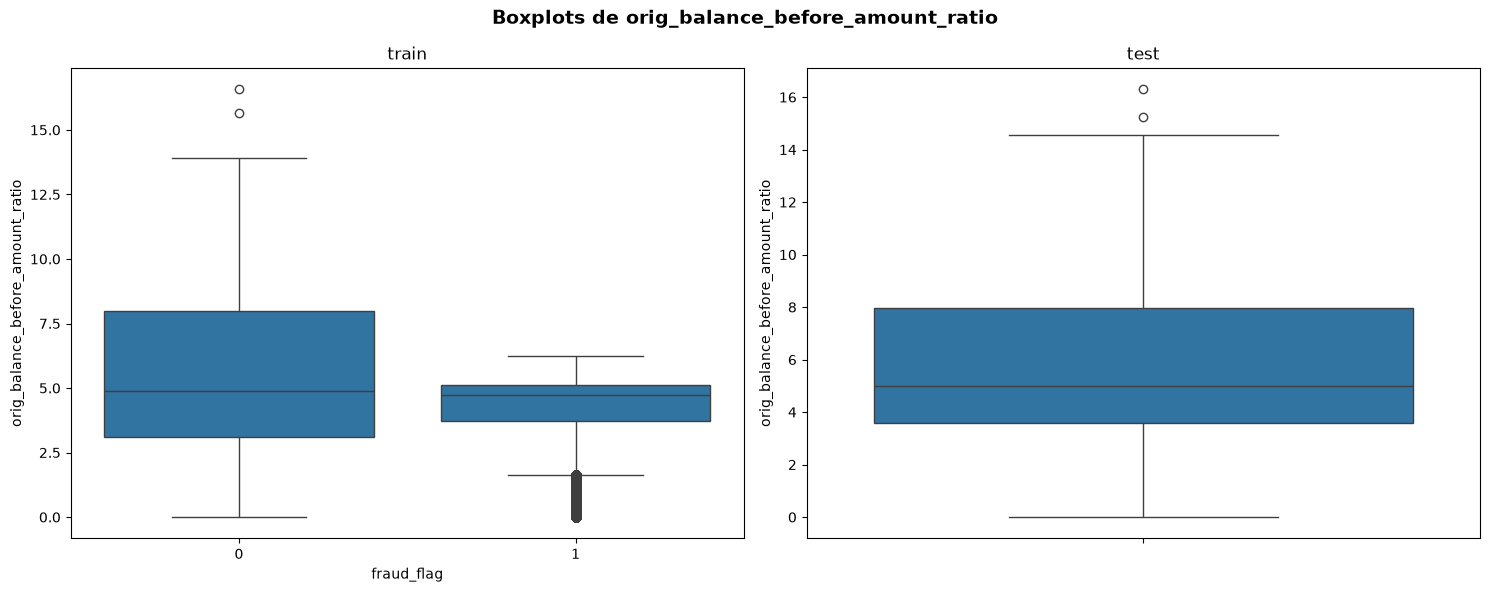

In [16]:
#orig_balance_before_amount_ratio : origin_balaance_before / amount

df_train['orig_balance_before_amount_ratio'] = np.log1p(np.abs(df_train['origin_balance_before'] / df_train['amount']).round(4))
df_test['orig_balance_before_amount_ratio'] = np.log1p(np.abs(df_test['origin_balance_before'] / df_test['amount']).round(4))

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Boxplots de orig_balance_before_amount_ratio", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.boxplot(df_train, x='fraud_flag', y='orig_balance_before_amount_ratio', ax=ax[0])

ax[1].set_title("test")
sns.boxplot(df_test['orig_balance_before_amount_ratio'], ax=ax[1])

plt.tight_layout()
plt.show()

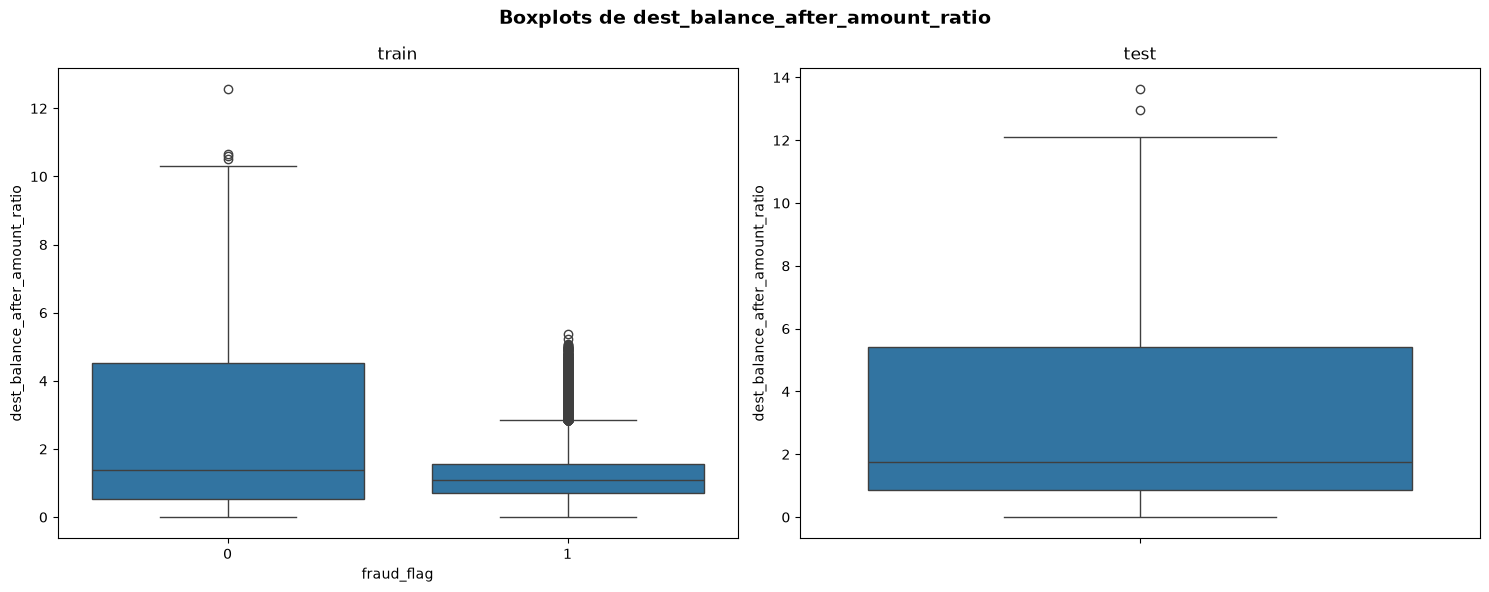

In [17]:
#dest_balance_after_amount_ratio : destination_balaance_after / amount

df_train['dest_balance_after_amount_ratio'] = np.log1p(np.abs(df_train['destination_balance_after'] / df_train['amount']).round(4))
df_test['dest_balance_after_amount_ratio'] = np.log1p(np.abs(df_test['destination_balance_after'] / df_test['amount']).round(4))

fig, ax= plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Boxplots de dest_balance_after_amount_ratio", fontweight='bold', fontsize=14)

ax[0].set_title("train")
sns.boxplot(df_train, x='fraud_flag', y='dest_balance_after_amount_ratio', ax=ax[0])

ax[1].set_title("test")
sns.boxplot(df_test['dest_balance_after_amount_ratio'], ax=ax[1])

plt.tight_layout()
plt.show()

In [18]:
df_train.head(25)

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag,type,orig_balance_check,error_origin_balance,dest_balance_check,error_destination_balance,was_transfert_blocked_before,was_transfert_blocked_after,is_op_03,log_amount,amount_class,prd_catg,orig_balance_before_amount_ratio,dest_balance_after_amount_ratio
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0,0,1,0.000000e+00,0,0.009950,0,0,0,6.457946,0,1,0.128041,1.095541
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0,0,0,6.456958e+00,0,6.456958,1,1,0,6.456958,0,1,0.114132,0.765607
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0,0,0,9.950331e-03,0,0.009950,0,0,0,6.525030,0,1,3.195083,1.136004
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0,0,0,3.637979e-12,1,0.000000,0,0,1,10.246240,1,1,0.015676,3.379688
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0,0,0,9.950331e-03,0,0.009950,0,0,1,11.367092,1,1,0.007770,0.693697
5,dtf_0000006_64d9bfcb,0,op_05,787.04,acc_o_6d8f4254f3f09623,25.81,25.81,acc_d_d2528fd81d284bd6,0.00,0.00,0,0,0,6.669549e+00,0,6.669549,1,1,0,6.669549,0,1,0.032274,0.000000
6,dtf_0000007_12c897cc,0,op_05,771.06,acc_o_6ad1fd4988e085ad,572637.44,571866.37,acc_d_256141e7a7c7947e,629.98,1401.04,0,0,0,9.950331e-03,1,0.000000,0,0,0,6.649062,0,1,6.611587,1.035672
7,dtf_0000008_2017ee18,0,op_05,758.83,acc_o_ed558e2b5b5af5f7,115.21,-643.62,acc_d_89927ea80de472e6,0.00,758.83,0,0,1,0.000000e+00,1,0.000000,0,0,0,6.633095,0,1,0.141326,0.693147
8,dtf_0000009_7388f093,0,op_03,96800.66,acc_o_9cc0fd44ac3f05d3,-658.41,-97459.06,acc_d_a0682983bf40c207,70.76,96871.41,1,0,0,9.950331e-03,0,0.009950,0,0,1,11.480419,1,1,0.006777,0.693497
9,dtf_0000010_c0647632,0,op_05,649.32,acc_o_d185654afcfec4e4,93.32,93.32,acc_d_4a34c3d6fd957589,706.31,706.31,0,0,0,6.477465e+00,0,6.477465,1,1,0,6.477465,0,1,0.134269,0.736111


In [19]:
print(df_train.info())
print()
print(df_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 24 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   id                                1290081 non-null  str    
 1   period                            1290081 non-null  int64  
 2   operation                         1290081 non-null  str    
 3   amount                            1290081 non-null  float64
 4   origin_account                    1290081 non-null  str    
 5   origin_balance_before             1290081 non-null  float64
 6   origin_balance_after              1290081 non-null  float64
 7   destination_account               1290081 non-null  str    
 8   destination_balance_before        1290081 non-null  float64
 9   destination_balance_after         1290081 non-null  float64
 10  fraud_flag                        1290081 non-null  int64  
 11  type                              1290081 non-nu

In [20]:
le = LabelEncoder()

df_train['operation'] = le.fit_transform(df_train['operation'])
df_test['operation'] = le.transform(df_test['operation'])

df_train.head()

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag,type,orig_balance_check,error_origin_balance,dest_balance_check,error_destination_balance,was_transfert_blocked_before,was_transfert_blocked_after,is_op_03,log_amount,amount_class,prd_catg,orig_balance_before_amount_ratio,dest_balance_after_amount_ratio
0,dtf_0000001_ffa5beb5,0,4,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0,0,1,0.000000e+00,0,0.009950,0,0,0,6.457946,0,1,0.128041,1.095541
1,dtf_0000002_61992e82,0,4,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0,0,0,6.456958e+00,0,6.456958,1,1,0,6.456958,0,1,0.114132,0.765607
2,dtf_0000003_9a123b6d,0,4,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0,0,0,9.950331e-03,0,0.009950,0,0,0,6.525030,0,1,3.195083,1.136004
3,dtf_0000004_240f3dae,0,2,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0,0,0,3.637979e-12,1,0.000000,0,0,1,10.246240,1,1,0.015676,3.379688
4,dtf_0000005_f18939e7,0,2,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0,0,0,9.950331e-03,0,0.009950,0,0,1,11.367092,1,1,0.007770,0.693697


## Modeling

In [21]:
#Split des donnees pour l'entrainement et le test

FEATURES = list(df_train.drop(['id', 'period', 'origin_account', 'destination_account', 'fraud_flag'], axis=1).columns)
TARGET = 'fraud_flag'
RANDOM_SEED = 42

X, y= df_train[FEATURES].values, df_train[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size= 0.3, random_state= RANDOM_SEED, shuffle=True)

print("=====Split des données=====")
print(f"    - X_train : {X_train.shape}")
print(f"    - X_test : {X_test.shape}")
print(f"    - y_train : {y_train.shape}")
print(f"    - y_test : {y_test.shape}")
print()
print("=====Proportion de lignes de fraude=====")
print(f"    - y_train : {((len(y_train[y_train==1]) / len(y_train)) * 100):.1f} %")
print(f"    - y_test : {((len(y_test[y_test==1]) / len(y_test)) * 100):.1f} %")

=====Split des données=====
    - X_train : (903056, 19)
    - X_test : (387025, 19)
    - y_train : (903056,)
    - y_test : (387025,)

=====Proportion de lignes de fraude=====
    - y_train : 10.0 %
    - y_test : 10.0 %


In [22]:
#Validation croisee XGBoost

N_SPLITS = 4
skf = StratifiedKFold(n_splits= N_SPLITS)

print(f"Début de la validation croisée ({N_SPLITS} folds) avec XGBoost...")
print("="*60)

prauc_scores, f1_scores= [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

    x_Train, x_Val = X_train[train_idx], X_train[val_idx]
    y_Train, y_Val = y_train[train_idx], y_train[val_idx]

    model = XGBClassifier(
        n_estimators= 500,
        learning_rate= 0.05,
        max_depth= 6,
        scale_pos_weight= 9,
        tree_method= 'hist',
        eval_metric= 'aucpr',
        random_state= RANDOM_SEED,
        n_jobs=-1
    )

    model.fit(
        x_Train, y_Train,
        eval_set= [(x_Val, y_Val)],
        verbose= False
    )

    y_probs = model.predict_proba(x_Val)[:, 1]
    y_preds= model.predict(x_Val)

    fold_prauc = average_precision_score(y_Val, y_probs)
    f1 = f1_score(y_Val, y_preds)

    prauc_scores.append(fold_prauc)
    f1_scores.append(f1)
    print(f"Fold {fold} | Score PR-AUC : {fold_prauc:.4f} -- F1-Score : {f1:.4f}")

print("="*60)
mean_prauc= np.mean(prauc_scores)
std_prauc= np.std(prauc_scores)
mean_f1 = np.mean(f1_scores)
std_f1= np.std(f1_scores)
print(f"Moyenne PR-AUC globale : {mean_prauc:.4f} (+/- {std_prauc:.4f})")
print(f"Moyenne F1-score globale : {mean_f1:.4f} (+/- {std_f1:.4f})")

Début de la validation croisée (4 folds) avec XGBoost...
Fold 1 | Score PR-AUC : 0.4239 -- F1-Score : 0.4890
Fold 2 | Score PR-AUC : 0.4242 -- F1-Score : 0.4911
Fold 3 | Score PR-AUC : 0.4241 -- F1-Score : 0.4910
Fold 4 | Score PR-AUC : 0.4271 -- F1-Score : 0.4908
Moyenne PR-AUC globale : 0.4248 (+/- 0.0013)
Moyenne F1-score globale : 0.4905 (+/- 0.0008)
